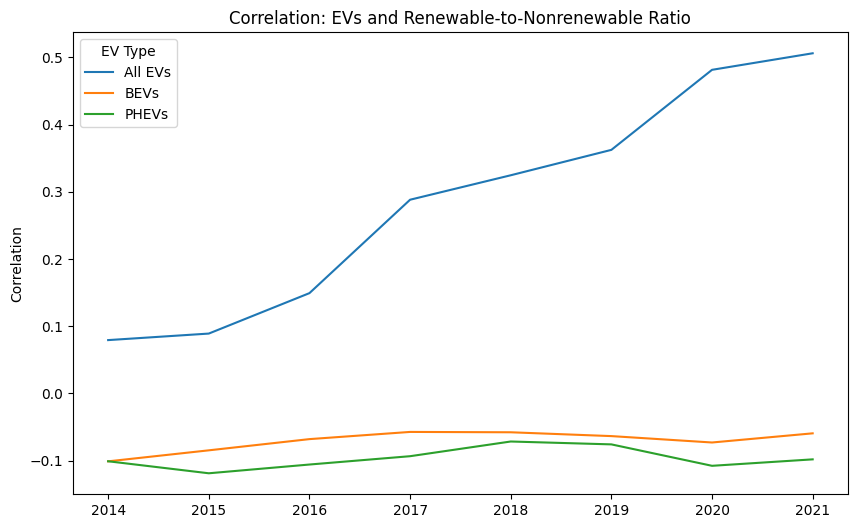

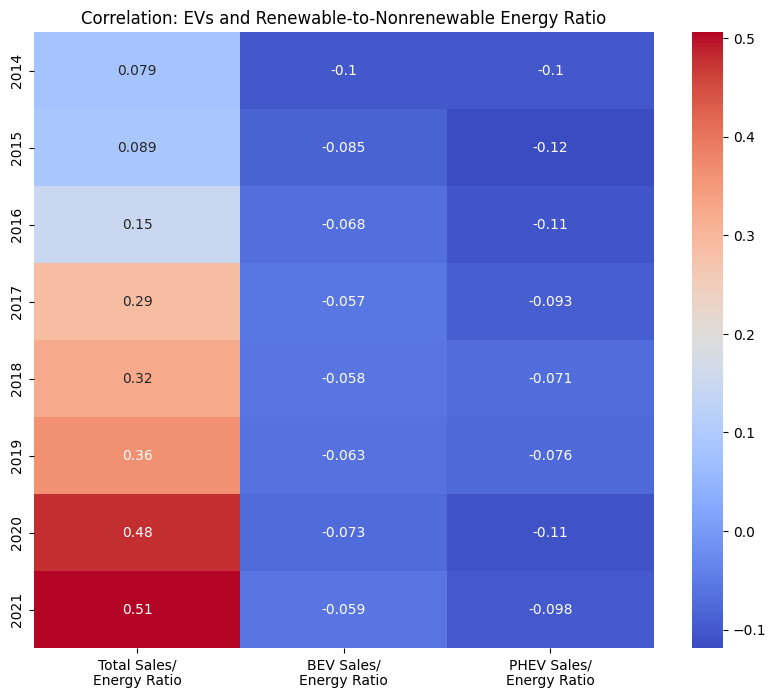

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

corr_ratio_df = pd.read_csv('corr_ratio.csv')
combined_data = pd.read_csv('combined_data.csv')

# Line Graph
plt.figure(figsize=(10, 6))
sns.lineplot(data=corr_ratio_df, x='year', y='corr_all_ratio', label='All EVs')
sns.lineplot(data=corr_ratio_df, x='year', y='corr_bev_ratio', label='BEVs')
sns.lineplot(data=corr_ratio_df, x='year', y='corr_phev_ratio', label='PHEVs')
plt.title("Correlation: EVs and Renewable-to-Nonrenewable Ratio")
plt.xlabel("")
plt.ylabel("Correlation")
plt.legend(title="EV Type")
plt.show()

# Heatmap: 

corr_ratio_df.rename(columns={'corr_all_ratio': 'Total Sales/\nEnergy Ratio',
                              'corr_bev_ratio': 'BEV Sales/\nEnergy Ratio',
                              'corr_phev_ratio': 'PHEV Sales/\nEnergy Ratio'}, inplace=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_ratio_df.set_index('year'), annot=True, cmap='coolwarm', cbar = True)
plt.title("Correlation: EVs and Renewable-to-Nonrenewable Energy Ratio")
plt.xlabel("")
plt.ylabel("")
plt.show()


In [7]:
# Define high and low EV adoption groups based on Total EV Sales (using the top 25% threshold)
threshold_ev_sales = combined_data['Total_Sales'].quantile(0.75)

# Divide data into high and low EV adoption groups
high_ev_adoption_group = combined_data[combined_data['Total_Sales'] > threshold_ev_sales]
low_ev_adoption_group = combined_data[combined_data['Total_Sales'] <= threshold_ev_sales]

# Perform a t-test to compare the renewable-to-nonrenewable ratio between high and low EV adoption groups
t_test_ratio_ev_adoption = ttest_ind(
    high_ev_adoption_group['ratio_renew_nonrenew'].dropna(),
    low_ev_adoption_group['ratio_renew_nonrenew'].dropna(),
    equal_var=False
)

t_test_ratio_ev_adoption


Ttest_indResult(statistic=2.5954533102937343, pvalue=0.011616455636607815)